# DEMI | NOVA FCT

## Fatigue Design of Mechanical Joints and Aerospace Structures

##### José Xavier & Rui Martins

### Problems 12 — Variable-amplitude loading and strain-life methods

- [Exercise 12.1](#ex1) — Rainflow counting for an irregular stress history
- [Exercise 12.2](#ex2) — Miner damage under block loading
- [Exercise 12.3](#ex3) — Modified Morrow strain–life equation
- [Exercise 12.4](#ex4) — Smith–Watson–Topper (SWT) mean-stress correction
- [Exercise 12.5](#ex5) — Fatemi–Socie critical-plane parameter
- [Exercise 12.6](#ex6) — Conceptual questions


In [1]:
import numpy as np
import matplotlib.pyplot as plt

FS = 14

# Reset to default style so any IDE dark-theme overrides do not bleed in.
plt.style.use('default')

plt.rcParams.update({
    'figure.figsize':   (10, 4.2), 'figure.dpi': 110,
    'font.family':      'serif',  'font.size': FS,
    'axes.grid':        True,     'grid.alpha': 0.30,
    'lines.linewidth':  2,
    # --- Backgrounds (white) ---
    'axes.facecolor':   'white',
    'figure.facecolor': 'white',
    'savefig.facecolor':'white',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black',
    # --- Force all text BLACK so the IDE dark theme does not hide it ---
    'text.color':       'black',
    'axes.labelcolor':  'black',
    'axes.edgecolor':   'black',
    'axes.titlecolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    'legend.labelcolor':'black',
})
COLORS = dict(curve='#1f4e79', point='#c0392b', accent='#8e44ad',
              guide='0.55', warn='#e67e22', cool='#16a085')

def brentq(f, a, b, args=(), tol=1e-10, maxit=200):
    '''Minimal bisection root-finder (numpy-only, no scipy dependency).'''
    fa, fb = f(a, *args), f(b, *args)
    if fa*fb > 0:
        raise ValueError(f'f(a) and f(b) must straddle zero ({fa}, {fb})')
    for _ in range(maxit):
        c = 0.5*(a+b)
        fc = f(c, *args)
        if abs(fc) < tol or 0.5*(b-a) < tol*max(1.0, abs(c)):
            return c
        if fa*fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return 0.5*(a+b)


---

## Formulary — Variable-amplitude and strain-life

**Rainflow counting** extracts closed hysteresis loops $(\sigma_{\max},
\sigma_{\min})\to(\Delta\sigma,\sigma_a,\sigma_m)$ from an irregular history.

**Basquin:** $\sigma_a = \sigma_f'\,(2N_f)^{b}$.

**Palmgren–Miner:** $D = \sum n_i/N_{f,i} \le 1$.

**Modified Morrow:**
\begin{equation*}
\varepsilon_a = \dfrac{\sigma_f' - \sigma_m}{E}(2N_f)^{b} + \varepsilon_f'(2N_f)^{c}.
\tag{F.1}\end{equation*}

**SWT:**
\begin{equation*}
\sigma_{\max}\varepsilon_a = \dfrac{(\sigma_f')^{2}}{E}(2N_f)^{2b} + \sigma_f'\varepsilon_f'(2N_f)^{b+c}.
\tag{F.2}\end{equation*}

**Fatemi–Socie:**
\begin{equation*}
FS = \dfrac{\Delta\gamma_{\max}}{2}\!\left(1 + k\dfrac{\sigma_{n,\max}}{\sigma_y}\right).
\tag{F.3}\end{equation*}


<a id='ex1'></a>
---

## Exercise 12.1 — Rainflow counting for an irregular stress history

A strain gauge mounted on an aircraft fuselage panel records the following stress-time history, expressed as a sequence of stress reversals in MPa:

$$
0 \rightarrow 120 \rightarrow -40 \rightarrow 80 \rightarrow -100 \rightarrow 140 \rightarrow 20 \rightarrow -60 \rightarrow 0.
$$

(a) Apply the rainflow counting method to the sequence of reversals.  
(b) For each counted cycle or half-cycle, determine the stress range $\Delta\sigma$, stress amplitude $\sigma_a$, mean stress $\sigma_m$ and cycle count.  
(c) Construct the corresponding rainflow matrix using stress range and mean stress bins.  
(d) Explain why rainflow counting is preferable to simple peak counting for fatigue damage assessment under variable-amplitude loading.  
(e) Implement the counting procedure in Python and present the results in tabular form.

### Solution


#### (a)–(b)–(e) Implement and apply the standard 4-point rainflow algorithm
(ASTM E1049). Each *closed* hysteresis loop is counted as one full cycle;
unmatched reversals at the end are *half* cycles.


In [2]:
def rainflow_count(seq):
    '''ASTM E1049 four-point rainflow counting (returns list of (range, mean, count)).'''
    cycles = []
    stack = []
    for x in seq:
        stack.append(float(x))
        while len(stack) >= 4:
            S1, S2, S3, S4 = stack[-4], stack[-3], stack[-2], stack[-1]
            X = abs(S3 - S2)
            Y = abs(S2 - S1)
            Z = abs(S4 - S3)
            # The interior pair (S2,S3) is a closed cycle if it is enclosed by both
            # the previous excursion (S1->S2) and the next (S3->S4).
            if X <= Y and X <= Z:
                rng = X
                mean = 0.5*(S2 + S3)
                cycles.append((rng, mean, 1.0))
                # remove S2,S3 (the interior pair)
                del stack[-3]; del stack[-2]
            else:
                break
    # Residual: count unmatched reversals as half cycles
    for i in range(len(stack)-1):
        rng = abs(stack[i+1] - stack[i])
        mean = 0.5*(stack[i+1] + stack[i])
        cycles.append((rng, mean, 0.5))
    return cycles

sequence = [0, 120, -40, 80, -100, 140, 20, -60, 0]
cycles = rainflow_count(sequence)
print('Rainflow cycles (full and half):')
print(f'{"Δσ":>6} {"σ_m":>7} {"σ_a":>6} {"count":>7}')
for rng, mean, cnt in sorted(cycles, key=lambda x: -x[0]):
    sa = rng/2
    print(f'{rng:6.0f} {mean:7.1f} {sa:6.1f} {cnt:7.1f}')
total = sum(c[2] for c in cycles)
print(f'\nTotal cycle count = {total}')


Rainflow cycles (full and half):
    Δσ     σ_m    σ_a   count
   240    20.0  120.0     0.5
   220    10.0  110.0     0.5
   120    20.0   60.0     1.0
   120    60.0   60.0     0.5
   120    80.0   60.0     0.5
    80   -20.0   40.0     0.5
    60   -30.0   30.0     0.5

Total cycle count = 4.0


#### (c) Rainflow matrix (range × mean bins)


Range × Mean matrix (count of cycles):
         mean∈[-100, -50) mean∈[ -50,  +0) mean∈[  +0, +50) mean∈[ +50,+100)
Δσ∈[  0, 50)              0.0              0.0              0.0              0.0
Δσ∈[ 50,100)              0.0              1.0              0.0              0.0
Δσ∈[100,150)              0.0              0.0              1.0              1.0
Δσ∈[150,200)              0.0              0.0              0.0              0.0
Δσ∈[200,250)              0.0              0.0              1.0              0.0


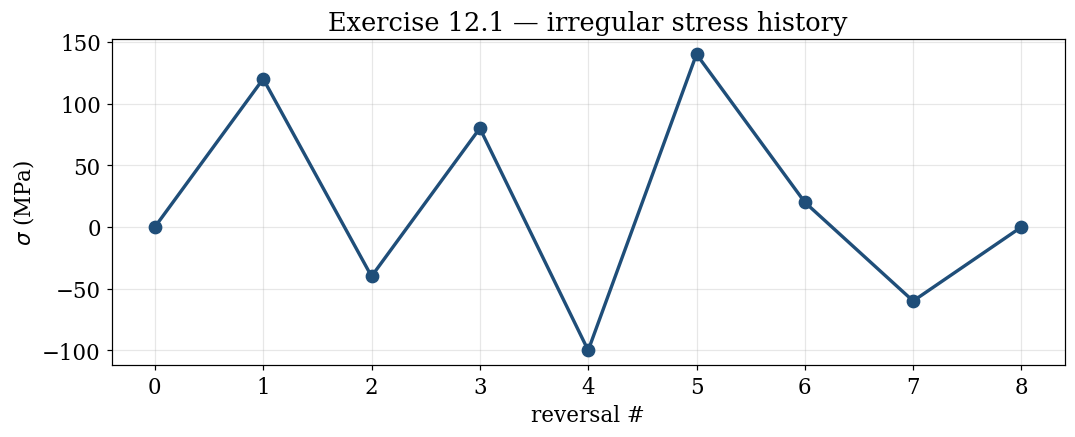

In [3]:
# Bin and tabulate
ranges = [c[0] for c in cycles]
means  = [c[1] for c in cycles]
counts = [c[2] for c in cycles]

range_bins = np.array([0, 50, 100, 150, 200, 250])
mean_bins  = np.array([-100, -50, 0, 50, 100])

matrix = np.zeros((len(range_bins)-1, len(mean_bins)-1))
for r, m_, c_ in zip(ranges, means, counts):
    i = np.searchsorted(range_bins, r, side='right') - 1
    j = np.searchsorted(mean_bins,  m_, side='right') - 1
    if 0 <= i < matrix.shape[0] and 0 <= j < matrix.shape[1]:
        matrix[i, j] += c_

# Show matrix
print('Range × Mean matrix (count of cycles):')
header = ' '*9 + ' '.join(f'mean∈[{mean_bins[k]:>+4d},{mean_bins[k+1]:>+4d})' for k in range(len(mean_bins)-1))
print(header)
for i in range(matrix.shape[0]):
    row = f'Δσ∈[{range_bins[i]:3d},{range_bins[i+1]:3d}) '
    row += ' '.join(f'{matrix[i,j]:>16.1f}' for j in range(matrix.shape[1]))
    print(row)

fig, ax = plt.subplots()
ax.plot(range(len(sequence)), sequence, 'o-', color=COLORS['curve'], lw=2.2, markersize=8)
ax.set_xlabel('reversal #'); ax.set_ylabel(r'$\sigma$ (MPa)')
ax.set_title('Exercise 12.1 — irregular stress history')
plt.tight_layout(); plt.show()


#### (d) Why rainflow over peak counting?

* **Peak counting** records every local maximum and minimum as an independent
  cycle, **double-counting** the contributions of small interior reversals.
* **Rainflow** identifies *closed* hysteresis loops in the stress–strain
  plane — these correspond to **actual material damage events** in metals
  (each closed loop is a single dissipative cycle).
* Damage prediction (Miner's rule) needs cycles that correspond to closed
  loops, not to arbitrary topological peaks. Rainflow is the standard
  (ASTM E1049, ISO 12110) precisely because it is mechanically faithful.


### Solution summary — Exercise 12.1

Rainflow-counted cycles (ASTM E1049, total = 4.0 cycles):

| $\Delta\sigma$ (MPa) | $\sigma_m$ (MPa) | $\sigma_a$ (MPa) | Count |
|---:|---:|---:|---:|
| 240 | 20.0 | 120.0 | 0.5 (half) |
| 220 | 10.0 | 110.0 | 0.5 (half) |
| 120 | 20.0 | 60.0 | **1.0** (full) |
| 120 | 60.0 | 60.0 | 0.5 (half) |
| 120 | 80.0 | 60.0 | 0.5 (half) |
| 80 | −20.0 | 40.0 | 0.5 (half) |
| 60 | −30.0 | 30.0 | 0.5 (half) |

**Total cycle count: 4.0** (1 full cycle + 6 half-cycles).

<a id='ex2'></a>
---

## Exercise 12.2 — Miner damage under block loading

An aluminium alloy component is subjected to the following repeated loading spectrum:

| Block | $\Delta\sigma$ (MPa) | $R$ | $n$ (cycles) |
|---:|---:|---:|---:|
| 1 | 180 | 0.1 | $2\times10^5$ |
| 2 | 140 | 0.1 | $8\times10^5$ |
| 3 | 220 | 0.1 | $5\times10^4$ |

The material follows the Basquin relation

$$
\sigma_a = \sigma_f'(2N_f)^b
$$

with

$$
\sigma_f' = 950~\text{MPa}, \qquad b=-0.095.
$$

(a) Compute the stress amplitude $\sigma_a$ for each block.  
(b) Determine the fatigue life $N_{f,i}$ associated with each block.  
(c) Compute the cumulative Miner damage $D=\sum n_i/N_{f,i}$.  
(d) Estimate the number of complete repeated spectra to failure.  
(e) Discuss the main limitations of Palmgren–Miner linear damage accumulation for aerospace structures subjected to overloads and underloads.

### Solution

In [4]:
# ------------------------------------------------------------
# Problem 12.2 — Variable-amplitude fatigue loading
# Basquin law + Palmgren–Miner damage rule
# ------------------------------------------------------------

# Basquin material parameters:
# σ_a = σ'_f (2N_f)^b
sigma_fp = 950.0   # fatigue strength coefficient, σ'_f [MPa]
b = -0.095         # fatigue strength exponent [-]

# Each block is defined as:
# (stress range Δσ [MPa], stress ratio R = σ_min/σ_max, number of cycles n)
blocks = [
    (420.0, 0.1, 2e5),
    (360.0, 0.1, 8e5),
    (480.0, 0.1, 5e4)
]

print("Basquin law:")
print("  σ_a = σ'_f (2N_f)^b")
print(f"  σ'_f = {sigma_fp:.1f} MPa")
print(f"  b    = {b:.3f}\n")

print("Block-by-block fatigue damage calculation:\n")

print(
    f'{"Block":>5} '
    f'{"Δσ":>8} '
    f'{"R":>6} '
    f'{"σ_max":>10} '
    f'{"σ_min":>10} '
    f'{"σ_a":>10} '
    f'{"σ_m":>10} '
    f'{"N_f":>14} '
    f'{"n":>12} '
    f'{"D_i=n/N_f":>14}'
)

D_total = 0.0

for i, (delta_sigma, R, n) in enumerate(blocks, start=1):

    # ------------------------------------------------------------
    # 1. Recover σ_max and σ_min from Δσ and R
    #
    # Δσ = σ_max - σ_min
    # R  = σ_min / σ_max  →  σ_min = R σ_max
    #
    # Therefore:
    # Δσ = σ_max - R σ_max = σ_max(1 - R)
    # σ_max = Δσ / (1 - R)
    # ------------------------------------------------------------

    sigma_max = delta_sigma / (1.0 - R)
    sigma_min = R * sigma_max

    # ------------------------------------------------------------
    # 2. Compute alternating and mean stresses
    #
    # σ_a = (σ_max - σ_min)/2 = Δσ/2
    # σ_m = (σ_max + σ_min)/2
    # ------------------------------------------------------------

    sigma_a = (sigma_max - sigma_min) / 2.0
    sigma_m = (sigma_max + sigma_min) / 2.0

    # ------------------------------------------------------------
    # 3. Fatigue life from Basquin law
    #
    # σ_a = σ'_f (2N_f)^b
    #
    # Rearranging:
    # 2N_f = (σ_a / σ'_f)^(1/b)
    # N_f  = 0.5 (σ_a / σ'_f)^(1/b)
    # ------------------------------------------------------------

    Nf = 0.5 * (sigma_a / sigma_fp) ** (1.0 / b)

    # ------------------------------------------------------------
    # 4. Palmgren–Miner damage for this block
    #
    # D_i = n_i / N_fi
    # ------------------------------------------------------------

    D_i = n / Nf
    D_total += D_i

    print(
        f'{i:5d} '
        f'{delta_sigma:8.1f} '
        f'{R:6.2f} '
        f'{sigma_max:10.1f} '
        f'{sigma_min:10.1f} '
        f'{sigma_a:10.1f} '
        f'{sigma_m:10.1f} '
        f'{Nf:14.3e} '
        f'{n:12.3e} '
        f'{D_i:14.5f}'
    )

print("\nMiner cumulative damage:")
print(f"  D = Σ(n_i/N_fi) = {D_total:.3f}")

if D_total < 1.0:
    spectra_to_failure = 1.0 / D_total
    print("\nFailure prediction:")
    print(f"  Since D < 1, one complete spectrum does not cause failure.")
    print(f"  Number of repeated spectra to failure ≈ 1/D = {spectra_to_failure:.2f}")
else:
    print("\nFailure prediction:")
    print("  Since D ≥ 1, failure is predicted within the first spectrum.")

Basquin law:
  σ_a = σ'_f (2N_f)^b
  σ'_f = 950.0 MPa
  b    = -0.095

Block-by-block fatigue damage calculation:

Block       Δσ      R      σ_max      σ_min        σ_a        σ_m            N_f            n      D_i=n/N_f
    1    420.0   0.10      466.7       46.7      210.0      256.7      3.972e+06    2.000e+05        0.05035
    2    360.0   0.10      400.0       40.0      180.0      220.0      2.012e+07    8.000e+05        0.03975
    3    480.0   0.10      533.3       53.3      240.0      293.3      9.740e+05    5.000e+04        0.05133

Miner cumulative damage:
  D = Σ(n_i/N_fi) = 0.141

Failure prediction:
  Since D < 1, one complete spectrum does not cause failure.
  Number of repeated spectra to failure ≈ 1/D = 7.07


#### (e) Limitations of Miner for aerospace structures

* **Sequence dependence** — Miner ignores history; H–L vs L–H sequences give
  factors of 2–3 difference in life.
* **Overload retardation** — large compressive RS at the crack tip after an
  OL slows subsequent CA growth (Wheeler, Willenborg).
* **Underload erasure** — a single compressive underload after an OL erases
  most of the retardation.
* **Below-fatigue-limit cycles** — Miner says they cause no damage, but in
  spectrum loading they propagate already-initiated cracks.

Aerospace damage-tolerance therefore complements Miner with retardation
models, strain-life PSWT correction, and conservative safety factors
(typically 2–4 on life).


### Solution summary — Exercise 12.2

$\sigma_f' = 950$ MPa, $b = -0.095$, $R = 0.1$ for all blocks.

| Block | $\Delta\sigma$ | $\sigma_a$ | $\sigma_m$ | $N_{f,i}$ | $n_i$ | $D_i = n_i/N_{f,i}$ |
|---:|---:|---:|---:|---:|---:|---:|
| 1 | 420 MPa | 210 MPa | 256.7 MPa | 3.972×10⁶ | 2.000×10⁵ | 0.0504 |
| 2 | 360 MPa | 180 MPa | 220.0 MPa | 2.012×10⁷ | 8.000×10⁵ | 0.0398 |
| 3 | 480 MPa | 240 MPa | 293.3 MPa | 9.740×10⁵ | 5.000×10⁴ | 0.0513 |
| — | — | — | **Total $D$** | — | — | **0.141** |

**Component survives one spectrum** ($D = 0.141 < 1$). Spectra to failure: **≈ 7.07**.

<a id='ex3'></a>
---

## Exercise 12.3 — Modified Morrow strain–life equation

A steel specimen is subjected to strain-controlled fatigue loading with total strain amplitude

$$
\varepsilon_a = 0.006
$$

and tensile mean stress

$$
\sigma_m = 150~\text{MPa}.
$$

The material properties are:

$$
\sigma_f' = 1050~\text{MPa}, \qquad
\varepsilon_f' = 0.22, \qquad
b=-0.09, \qquad c=-0.58, \qquad
E = 210~\text{GPa}.
$$

The modified Morrow relation is

$$
\varepsilon_a =
\frac{\sigma_f'-\sigma_m}{E}(2N_f)^b
+
\varepsilon_f'(2N_f)^c.
$$

(a) Determine the fatigue life $N_f$ numerically.

(b) Repeat the calculation for $\sigma_m=0$.  

(c) Quantify the influence of tensile mean stress on fatigue life.

(d) Plot the elastic and plastic strain-life contributions as a function of $N_f$.

(e) Explain why strain-life methods are particularly relevant for low-cycle fatigue.

### Solution



In [5]:
sigma_fp, eps_fp = 1050.0, 0.22
b, c = -0.09, -0.58
E = 210e3
eps_a = 0.006

def morrow_resid(Nf, sigma_m):
    e_e = (sigma_fp - sigma_m)/E * (2*Nf)**b
    e_p = eps_fp * (2*Nf)**c
    return e_e + e_p - eps_a

# (a) σ_m = 150 MPa
Nf_a = brentq(morrow_resid, 1.0, 1e10, args=(150.0,))
print(f'(a) σ_m = 150 MPa  →  N_f = {Nf_a:.3e} cycles')

# (b) σ_m = 0
Nf_b = brentq(morrow_resid, 1.0, 1e10, args=(0.0,))
print(f'(b) σ_m = 0        →  N_f = {Nf_b:.3e} cycles')

# (c) Influence
print(f'(c) Tensile σ_m = 150 MPa shortens life by factor {Nf_b/Nf_a:.2f}× '
      f'({(Nf_a/Nf_b-1)*100:+.1f}%)')


(a) σ_m = 150 MPa  →  N_f = 5.664e+02 cycles
(b) σ_m = 0        →  N_f = 6.681e+02 cycles
(c) Tensile σ_m = 150 MPa shortens life by factor 1.18× (-15.2%)


#### (d) Elastic vs plastic strain–life contributions


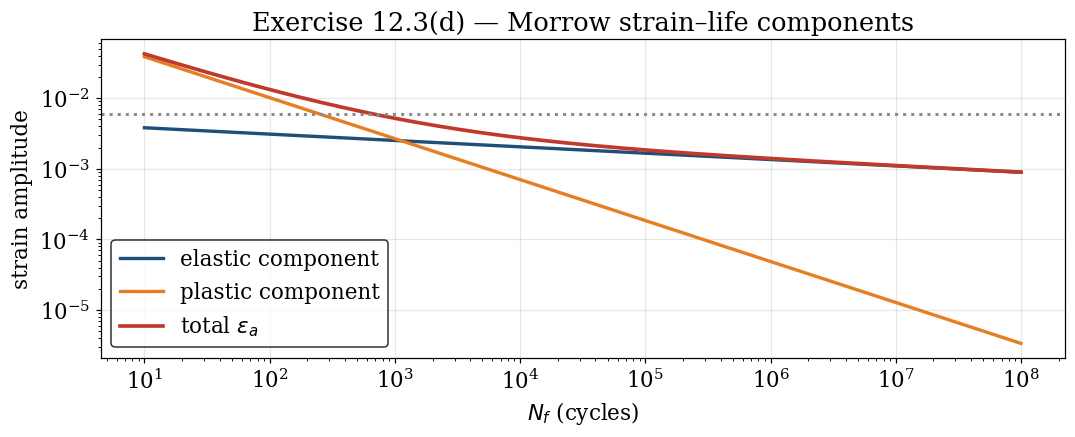

In [6]:
Nf_arr = np.logspace(1, 8, 400)
eps_e = (sigma_fp - 0)/E * (2*Nf_arr)**b
eps_p = eps_fp * (2*Nf_arr)**c
eps_t = eps_e + eps_p

fig, ax = plt.subplots()
ax.loglog(Nf_arr, eps_e, color=COLORS['curve'], lw=2.2, label='elastic component')
ax.loglog(Nf_arr, eps_p, color=COLORS['warn'],  lw=2.2, label='plastic component')
ax.loglog(Nf_arr, eps_t, color=COLORS['point'], lw=2.4, label='total $\\varepsilon_a$')
ax.axhline(eps_a, color=COLORS['guide'], ls=':')
ax.set_xlabel(r'$N_f$ (cycles)'); ax.set_ylabel(r'strain amplitude')
ax.set_title('Exercise 12.3(d) — Morrow strain–life components')
ax.legend(); plt.tight_layout(); plt.show()


#### (e) Why strain-life for LCF?

Below ~$10^{4}$ cycles the plastic strain amplitude is comparable to the
elastic part — the Basquin relation (purely elastic stress–life) fails.
The Coffin–Manson plastic term $\varepsilon_f'(2N_f)^{c}$ captures the
cyclic plastic strain that drives intrusions/extrusions at slip bands;
combining elastic + plastic gives a single relation valid from $10^{1}$ to
$10^{8}$ cycles.


### Solution summary — Exercise 12.3

$\varepsilon_a = 0.006$; $\sigma_f' = 1050$ MPa, $\varepsilon_f' = 0.22$, $b=-0.09$, $c=-0.58$, $E=210$ GPa.

| Condition | $\sigma_m$ | $N_f$ (Modified Morrow) |
|---|---:|---:|
| With mean stress | 150 MPa | **5.664×10² cycles** |
| Zero mean stress | 0 MPa | **6.681×10² cycles** |

Tensile $\sigma_m = 150$ MPa shortens life by a factor of **1.18×** (−15.2 %).

<a id='ex4'></a>
---

## Exercise 12.4 — Smith–Watson–Topper mean-stress correction

A fatigue-critical location in an aircraft landing-gear component is subjected to a local cycle with

$$
\sigma_{\max}=420~\text{MPa}, \qquad \varepsilon_a = 0.0045.
$$

The SWT parameter is defined as

$$
SWT = \sigma_{\max}\varepsilon_a.
$$

The corresponding strain-life equation is

$$
\sigma_{\max}\varepsilon_a =
\frac{(\sigma_f')^2}{E}(2N_f)^{2b}
+
\sigma_f'\varepsilon_f'(2N_f)^{b+c}.
$$

Use the following material properties:

$$
\sigma_f'=1100~\text{MPa}, \qquad
\varepsilon_f'=0.20, \qquad
b=-0.085, \qquad c=-0.55, \qquad
E=210~\text{GPa}.
$$

(a) Compute the SWT parameter.

(b) Determine the fatigue life $N_f$ numerically.  

(c) Compare the physical interpretation of SWT with the modified Morrow mean-stress correction.

(d) Discuss why $\sigma_{\max}$ is an important variable in fatigue problems involving tensile mean stress.

(e) Implement the solution in Python using a root-finding procedure.

### Solution



(a) SWT = σ_max · ε_a = 420.0·0.0045 = 1.8900
(b) N_f from SWT = 4.600e+03 cycles


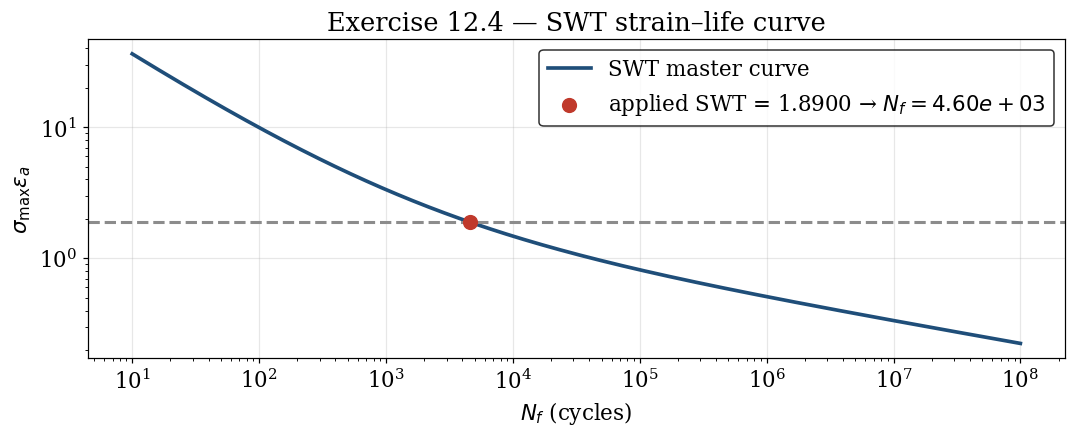

In [7]:
sigma_fp, eps_fp = 1100.0, 0.20
b, c = -0.085, -0.55
E = 210e3
sigma_max = 420.0
eps_a = 0.0045

SWT = sigma_max*eps_a
print(f'(a) SWT = σ_max · ε_a = {sigma_max}·{eps_a} = {SWT:.4f}')

def swt_resid(Nf):
    return (sigma_fp**2/E)*(2*Nf)**(2*b) + sigma_fp*eps_fp*(2*Nf)**(b+c) - SWT

Nf = brentq(swt_resid, 1.0, 1e10)
print(f'(b) N_f from SWT = {Nf:.3e} cycles')

# Visualise the SWT curve
Nf_arr = np.logspace(1, 8, 400)
SWT_arr = (sigma_fp**2/E)*(2*Nf_arr)**(2*b) + sigma_fp*eps_fp*(2*Nf_arr)**(b+c)
fig, ax = plt.subplots()
ax.loglog(Nf_arr, SWT_arr, color=COLORS['curve'], lw=2.4, label='SWT master curve')
ax.axhline(SWT, color=COLORS['guide'], ls='--')
ax.scatter([Nf], [SWT], color=COLORS['point'], s=80, zorder=5,
           label=f'applied SWT = {SWT:.4f} → $N_f={Nf:.2e}$')
ax.set_xlabel(r'$N_f$ (cycles)'); ax.set_ylabel(r'$\sigma_{\max}\varepsilon_a$')
ax.set_title('Exercise 12.4 — SWT strain–life curve')
ax.legend(); plt.tight_layout(); plt.show()


#### (c) SWT vs. Modified Morrow

* **Morrow** corrects the elastic Basquin term by subtracting $\sigma_m$ from
  $\sigma_f'$. Mean stress shifts the **elastic** part only; plastic part is
  untouched. Predicts that compressive $\sigma_m$ extends life and tensile
  shortens it.
* **SWT** uses the product $\sigma_{\max}\varepsilon_a$ as the *single*
  damage parameter. Mean stress enters through $\sigma_{\max}$ in both terms.
  Conservatively predicts **no fatigue damage** when $\sigma_{\max}\le 0$
  (the criterion is undefined — protective in compression-only cycles).

SWT is the default in **automotive and aerospace strain-life codes** (FEMFAT,
nCode) because it is simpler than Morrow and gives a single damage parameter
amenable to rainflow + multiaxial extensions.

#### (d) Why $\sigma_{\max}$ matters

$\sigma_{\max}$ controls **crack opening**: closed cracks do not propagate.
Two cycles with the same $\Delta\sigma$ but different $\sigma_{\max}$ have
*different* crack-opening times and *different* damage. SWT preserves this
through the $\sigma_{\max}\varepsilon_a$ product.


### Solution summary — Exercise 12.4

$\sigma_{\max} = 420$ MPa, $\varepsilon_a = 0.0045$; $\sigma_f' = 1100$ MPa, $\varepsilon_f' = 0.20$, $b=-0.085$, $c=-0.55$, $E=210$ GPa.

| Quantity | Value |
|---|---|
| SWT parameter $= \sigma_{\max}\varepsilon_a$ | **1.8900** |
| Fatigue life $N_f$ (SWT equation) | **4.600×10³ cycles** |

<a id='ex5'></a>
---

## Exercise 12.5 — Fatemi–Socie critical-plane parameter

A titanium alloy component is subjected to proportional combined tension–torsion loading. At a critical material point, the following quantities are obtained on the critical plane:

$$
\gamma_a = 0.008, \qquad \sigma_{n,\max}=320~\text{MPa}.
$$

The material has yield stress

$$
\sigma_y = 920~\text{MPa},
$$

and the Fatemi–Socie material parameter is assumed to be

$$
k=0.5.
$$

The Fatemi–Socie parameter is

$$
FS =
\frac{\Delta\gamma_{\max}}{2}
\left(
1+k\frac{\sigma_{n,\max}}{\sigma_y}
\right).
$$

(a) Compute $\Delta\gamma_{\max}$ from the shear strain amplitude.  
(b) Compute the Fatemi–Socie parameter.  
(c) Explain the physical meaning of the normal-stress correction term.  
(d) Discuss why critical-plane methods are required for multiaxial fatigue assessment.  
(e) Compare, conceptually, Fatemi–Socie with a uniaxial strain-life approach.

### Solution


In [8]:
gamma_a, sigma_n_max, sigma_y, k = 0.008, 320.0, 920.0, 0.5
dgamma_max = 2*gamma_a                              # Δγ = 2 γ_a
FS = (dgamma_max/2)*(1 + k*sigma_n_max/sigma_y)
print(f'(a) Δγ_max = 2·γ_a = {dgamma_max}')
print(f'(b) FS = (Δγ_max/2)·(1 + k·σ_n,max/σ_y)')
print(f'        = {gamma_a}·(1 + {k}·{sigma_n_max}/{sigma_y})')
print(f'        = {FS:.5f}')


(a) Δγ_max = 2·γ_a = 0.016
(b) FS = (Δγ_max/2)·(1 + k·σ_n,max/σ_y)
        = 0.008·(1 + 0.5·320.0/920.0)
        = 0.00939


#### (c) Physical meaning of the normal-stress correction

Microcracks initiate on slip bands and propagate along them. The driving
force is **shear strain** on the slip plane. However, a tensile normal stress
on that plane *opens* the microcrack, exposing new surface, and accelerates
propagation. The factor $(1+k\sigma_{n,\max}/\sigma_y)$ adds the
*facilitating effect* of the normal stress; $k$ is calibrated against
combined tension–torsion data (typically $k\sim 0.3$–$1.0$).

#### (d) Why critical-plane methods?

Under multiaxial loading, the principal-stress direction may rotate during a
cycle (non-proportional loading) or the maximum shear plane may not coincide
with the maximum principal-stress plane. Classical equivalent stresses
(von Mises, Tresca) average out the directionality and *under-predict*
damage. A critical-plane method searches over all material planes for the
one that maximises a damage parameter ($FS$, $SWT$ in shear form, MWB) and
predicts initiation on that plane.

#### (e) Fatemi–Socie vs uniaxial strain-life

Uniaxial $\varepsilon$–$N$ uses a *scalar* strain measure ($\varepsilon_a$
or $SWT$) — adequate when one principal direction dominates. $FS$
explicitly retains the **plane** information: a shear amplitude and the
normal stress on the *same* plane. Required whenever the loading is
non-proportional or when the geometry forces shear and normal cycles to be
out of phase (e.g. surface contact, fretting, axles in combined
torsion–bending).


### Solution summary — Exercise 12.5

$\gamma_a = 0.008$, $\sigma_{n,\max} = 320$ MPa, $\sigma_y = 920$ MPa, $k = 0.5$.

| Quantity | Value |
|---|---|
| Shear strain range $\Delta\gamma_{\max} = 2\gamma_a$ | 0.016 |
| Fatemi–Socie parameter $FS$ | **0.00939** |

<a id='ex6'></a>
---

## Exercise 12.6 — Conceptual questions on variable-amplitude and multiaxial fatigue

(a) What is the main purpose of cycle counting in fatigue analysis?  
(b) Why can the sequence of loading cycles affect fatigue life even when the same set of cycles is applied?  
(c) What is the physical difference between low-cycle fatigue and high-cycle fatigue from the viewpoint of strain-life methods?  
(d) Why are mean-stress corrections needed in fatigue-life prediction?  
(e) In multiaxial fatigue, why may the maximum principal stress plane not coincide with the critical fatigue damage plane?  
(f) What additional difficulties arise under non-proportional multiaxial loading?

### Solution


**(a) Purpose of cycle counting.** Reduce an arbitrary stress/strain history
to a discrete set of cycles that correspond to **closed hysteresis loops** so
that fatigue damage can be evaluated cycle-by-cycle via a damage rule
(Miner, PSWT, FS).

**(b) Sequence dependence.** Real materials have **memory**: each large
cycle plasticises the crack tip and leaves a compressive residual stress
field. The next cycle sees a different effective $\Delta K$ depending on
what happened before. Two histories with the same rainflow content but a
different *order* give different lives.

**(c) LCF vs HCF (strain-life view).**

* HCF — strain is dominated by the **elastic** part, fatigue is initiation-
  controlled, surface effects matter, life $>10^{4}$–$10^{5}$ cycles.
* LCF — the **plastic** strain amplitude is comparable to or larger than the
  elastic, bulk plasticity controls life, fewer cycles to failure ($<10^{4}$).
  Strain-life methods (Coffin–Manson) are essential because stress-life
  (Basquin) fails when significant plasticity is present.

**(d) Why mean-stress corrections?**

A tensile mean stress shifts the operating point upward in the
$(\sigma_m,\sigma_a)$ plane, closer to the failure envelope (Soderberg,
Goodman). Strain-life methods correct for this either through Morrow
($\sigma_f'-\sigma_m$) or SWT ($\sigma_{\max}\varepsilon_a$). Neglecting
mean stress under-predicts damage for $\sigma_m>0$.

**(e) Maximum principal vs critical fatigue plane.**

The maximum principal stress plane is the plane where $\sigma_n$ is largest.
The fatigue crack initiates on the plane that **maximises a damage
parameter**, which is typically dominated by **shear strain** (Stage I
slip-band crack growth). For ductile metals these two planes do not
coincide — the critical plane is closer to 45° from the maximum principal
direction.

**(f) Non-proportional loading difficulties.**

* **Out-of-phase rotation** of the principal axes makes the "critical plane"
  itself time-dependent.
* **Hysteresis** in stress–strain (Bauschinger, kinematic hardening) means
  the path through the stress space matters.
* Additional **hardening** under non-proportional cycles is observed in some
  alloys (stainless steels) — the cyclic stress amplitude is *higher* than
  under proportional cycles of the same equivalent strain range.
* Damage **accumulates on different planes** through the cycle, requiring
  an integral over plane orientations rather than a single maximum search.

Non-proportional multiaxial fatigue is one of the most challenging open
problems in the field.


---

### Final remarks

* Rainflow + Miner is the **industry standard** for VA loading; aerospace
  augments it with retardation models, strain-life PSWT, and safety factors.
* The strain-life framework (Morrow, SWT, FS) extends the S–N approach to
  LCF and to multiaxial loading — at the cost of needing **local stress and
  strain** at the critical point (FEM or Neuber's rule).
* The Fatemi–Socie parameter (Ex 12.5) is the de-facto standard for ductile
  multiaxial fatigue; the Brown–Miller and Smith–Watson–Topper variants are
  also widely used.


---

Copyright (c) DEMI - NOVA FCT

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>

Parts of this notebook were prepared with AI assistance (<a href="https://www.anthropic.com/claude-code" target="_blank">Claude Code</a>, Anthropic), reviewed and verified by the author.